# Part 2: Building Footprint Segmentation
**PhD Technical Assessment — UNLV Dept. of Civil & Environmental Engineering and Construction, Dr. Sohn's Research Lab**

Prepared by: Nuzhat Raisa

The workflow covers, in order:

1. **Data acquisition & verification**
2. **Leakage-safe dataset partitioning**
3. **Model, loss, and metrics**
4. **Training**
5. **Full-resolution inference & evaluation**
6. **Observation**

---

##**1. Data Acquisition and Verification**

##Connect Google Drive



In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##Find uploaded Inria files

In [ ]:
!find "/content/drive/MyDrive" -name "aerialimagelabeling.7z.*" -type f

/content/drive/MyDrive/InriaDataset/aerialimagelabeling.7z.001
/content/drive/MyDrive/InriaDataset/aerialimagelabeling.7z.002
/content/drive/MyDrive/InriaDataset/aerialimagelabeling.7z.003
/content/drive/MyDrive/InriaDataset/aerialimagelabeling.7z.005
/content/drive/MyDrive/InriaDataset/aerialimagelabeling.7z.004


##Check the file sizes first


In [ ]:
!ls -lh "/content/drive/MyDrive/InriaDataset/"

total 20G
-rw------- 1 root root 4.0G Sep 23 05:01 aerialimagelabeling.7z.001
-rw------- 1 root root 4.0G Sep 23 05:30 aerialimagelabeling.7z.002
-rw------- 1 root root 4.0G Sep 23 06:07 aerialimagelabeling.7z.003
-rw------- 1 root root 4.0G Sep 23 07:01 aerialimagelabeling.7z.004
-rw------- 1 root root 3.6G Sep 23 06:39 aerialimagelabeling.7z.005


##Install 7-Zip

In [ ]:
!apt-get update -qq
!apt-get install -y p7zip-full

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
p7zip-full is already the newest version (16.02+transitional.1).
0 upgraded, 0 newly installed, 0 to remove and 36 not upgraded.


##Create the extraction folder

In [ ]:
import os

extract_path = "/content/drive/MyDrive/InriaDataset/extracted"
os.makedirs(extract_path, exist_ok=True)

print("Dataset will be extracted to:")
print(extract_path)

Dataset will be extracted to:
/content/drive/MyDrive/InriaDataset/extracted


##Extract the dataset

In [ ]:
!7z x "/content/drive/MyDrive/InriaDataset/aerialimagelabeling.7z.001" \
-o"/content/drive/MyDrive/InriaDataset/extracted" -y


7-Zip 23.01 (x64) : Copyright (c) 1999-2023 Igor Pavlov : 2023-06-20
 64-bit locale=en_US.UTF-8 Threads:2 OPEN_MAX:1048576

Scanning the drive for archives:
  0M Scan /content/drive/MyDrive/InriaDataset/                                              1 file, 4294967296 bytes (4096 MiB)

Extracting archive: /content/drive/MyDrive/InriaDataset/aerialimagelabeling.7z.001
  0% 1 Open             0% 3 Open             0% 5 Open           --
Path = /content/drive/MyDrive/InriaDataset/aerialimagelabeling.7z.001
Type = Split
Physical Size = 4294967296
Volumes = 5
Total Physical Size = 20957265875
----
Path = aerialimagelabeling.7z
Size = 20957265875
--
Path = aerialimagelabeling.7z
Type = 7z
Physical Size = 20957265875
Headers Size = 150
Method = Copy
Solid = -
Blocks = 1

  0%      0% - NEW2-AerialImageDataset.zip

##Check the extracted folder structure

In [ ]:
import os

base_path = "/content/drive/MyDrive/InriaDataset/extracted"

for root, dirs, files in os.walk(base_path):
    level = root.replace(base_path, "").count(os.sep)

    if level <= 3:
        indent = "    " * level
        print(f"{indent}{os.path.basename(root)}/")

        for file in files[:5]:
            print(f"{indent}    {file}")

extracted/
    NEW2-AerialImageDataset.zip


##Count the image files

In [ ]:
from pathlib import Path

base_path = Path("/content/drive/MyDrive/InriaDataset/extracted")

tif_files = list(base_path.rglob("*.tif"))

print("Total .tif files:", len(tif_files))

print("\nFirst 20 files:")
for f in tif_files[:20]:
    print(f)

Total .tif files: 0

First 20 files:


##Check the ZIP before extracting

In [ ]:
import os

zip_path = "/content/drive/MyDrive/InriaDataset/extracted/NEW2-AerialImageDataset.zip"

size_gb = os.path.getsize(zip_path) / (1024**3)

print(f"ZIP file size: {size_gb:.2f} GB")
print("ZIP exists:", os.path.exists(zip_path))

ZIP file size: 19.52 GB
ZIP exists: True


##Extract the inner ZIP

In [ ]:
import os

dataset_path = "/content/drive/MyDrive/InriaDataset/extracted/Inria_Aerial_Dataset"
os.makedirs(dataset_path, exist_ok=True)

print(dataset_path)

/content/drive/MyDrive/InriaDataset/extracted/Inria_Aerial_Dataset


##Extract

In [ ]:
!unzip -q "/content/drive/MyDrive/InriaDataset/extracted/NEW2-AerialImageDataset.zip" \
-d "/content/drive/MyDrive/InriaDataset/extracted/Inria_Aerial_Dataset"

##Check the actual dataset

In [ ]:
from pathlib import Path

dataset_path = Path(
    "/content/drive/MyDrive/InriaDataset/extracted/Inria_Aerial_Dataset"
)

tif_files = list(dataset_path.rglob("*.tif"))

print("Total .tif files:", len(tif_files))

print("\nFirst 20 files:")
for f in tif_files[:20]:
    print(f)

Total .tif files: 540

First 20 files:
/content/drive/MyDrive/InriaDataset/extracted/Inria_Aerial_Dataset/AerialImageDataset/train/gt/austin1.tif
/content/drive/MyDrive/InriaDataset/extracted/Inria_Aerial_Dataset/AerialImageDataset/train/gt/austin10.tif
/content/drive/MyDrive/InriaDataset/extracted/Inria_Aerial_Dataset/AerialImageDataset/train/gt/austin11.tif
/content/drive/MyDrive/InriaDataset/extracted/Inria_Aerial_Dataset/AerialImageDataset/train/gt/austin12.tif
/content/drive/MyDrive/InriaDataset/extracted/Inria_Aerial_Dataset/AerialImageDataset/train/gt/austin13.tif
/content/drive/MyDrive/InriaDataset/extracted/Inria_Aerial_Dataset/AerialImageDataset/train/gt/austin14.tif
/content/drive/MyDrive/InriaDataset/extracted/Inria_Aerial_Dataset/AerialImageDataset/train/gt/austin15.tif
/content/drive/MyDrive/InriaDataset/extracted/Inria_Aerial_Dataset/AerialImageDataset/train/gt/austin16.tif
/content/drive/MyDrive/InriaDataset/extracted/Inria_Aerial_Dataset/AerialImageDataset/train/gt/aus

##Show the dataset folders clearly

In [ ]:
from pathlib import Path

dataset_path = Path(
    "/content/drive/MyDrive/InriaDataset/extracted/Inria_Aerial_Dataset"
)

print("Dataset folder structure:\n")

for path in sorted(dataset_path.rglob("*")):
    if path.is_dir():
        relative = path.relative_to(dataset_path)

        # Only show first few directory levels
        if len(relative.parts) <= 4:
            print(relative)

Dataset folder structure:

AerialImageDataset
AerialImageDataset/test
AerialImageDataset/test/images
AerialImageDataset/train
AerialImageDataset/train/gt
AerialImageDataset/train/images


##Count TIFF files by folder

In [ ]:
from collections import Counter

folder_counts = Counter()

for f in dataset_path.rglob("*.tif"):
    relative_folder = f.parent.relative_to(dataset_path)
    folder_counts[str(relative_folder)] += 1

print("Number of TIFF files in each folder:\n")

for folder, count in sorted(folder_counts.items()):
    print(f"{count:4d} files  ->  {folder}")

Number of TIFF files in each folder:

 180 files  ->  AerialImageDataset/test/images
 180 files  ->  AerialImageDataset/train/gt
 180 files  ->  AerialImageDataset/train/images


##Show short filenames

In [ ]:
tif_files = list(dataset_path.rglob("*.tif"))

for f in tif_files[:30]:
    print(f.parent.name, " -> ", f.name)

gt  ->  austin1.tif
gt  ->  austin10.tif
gt  ->  austin11.tif
gt  ->  austin12.tif
gt  ->  austin13.tif
gt  ->  austin14.tif
gt  ->  austin15.tif
gt  ->  austin16.tif
gt  ->  austin17.tif
gt  ->  austin18.tif
gt  ->  austin19.tif
gt  ->  austin2.tif
gt  ->  austin20.tif
gt  ->  austin21.tif
gt  ->  austin22.tif
gt  ->  austin23.tif
gt  ->  austin24.tif
gt  ->  austin25.tif
gt  ->  austin26.tif
gt  ->  austin27.tif
gt  ->  austin28.tif
gt  ->  austin29.tif
gt  ->  austin3.tif
gt  ->  austin30.tif
gt  ->  austin31.tif
gt  ->  austin32.tif
gt  ->  austin33.tif
gt  ->  austin34.tif
gt  ->  austin35.tif
gt  ->  austin36.tif


## **Dataset Preparation and Verification**

The extracted dataset contains labeled training images, corresponding ground-truth building masks, and a separate unlabeled test set. Because the official Inria test labels are withheld (a known property of this benchmark), only the **labeled** image–mask pairs (the `train/` folder, 180 tiles) are usable for supervised training and for any evaluation with ground truth to compare against.




In [ ]:
from pathlib import Path

root = Path(
    "/content/drive/MyDrive/InriaDataset/extracted/"
    "Inria_Aerial_Dataset/AerialImageDataset"
)

image_dir = root / "train" / "images"
mask_dir  = root / "train" / "gt"
official_test_dir = root / "test" / "images"

train_images = sorted(image_dir.glob("*.tif"))
train_masks  = sorted(mask_dir.glob("*.tif"))
test_images  = sorted(official_test_dir.glob("*.tif"))

print("Labeled images       :", len(train_images))
print("Ground-truth masks   :", len(train_masks))
print("Unlabeled test images:", len(test_images))

Labeled images       : 180
Ground-truth masks   : 180
Unlabeled test images: 180


Now lets verify that every labeled image has the corresponding mask:

In [ ]:
image_names = {f.name for f in train_images}
mask_names  = {f.name for f in train_masks}

print("Images without masks:", image_names - mask_names)
print("Masks without images:", mask_names - image_names)

if image_names == mask_names:
    print("\nAll labeled images have matching ground-truth masks.")

Images without masks: set()
Masks without images: set()

All labeled images have matching ground-truth masks.


## 2. Leakage-Safe Dataset Partitioning

Before deciding how to split the data, the first step is simply to confirm which cities are present and how many tiles each contributes.


##Identify the cities

In [ ]:
import re
from collections import Counter

def get_city(filename):
    return re.match(r"[A-Za-z]+", filename).group().lower()

city_counts = Counter(
    get_city(f.stem)
    for f in train_images
)

print("Labeled images by city:\n")

for city, count in sorted(city_counts.items()):
    print(f"{city:12s}: {count}")

Labeled images by city:

austin      : 36
chicago     : 36
kitsap      : 36
tyrol       : 36
vienna      : 36


### Leakage-Aware Dataset Partition

The labeled dataset contains five geographic regions — Austin, Chicago, Kitsap, Tyrol, and Vienna — with 36 aerial tiles each (180 tiles total). Two different leakage risks need separate fixes:

- **Tile-level leakage:** since patches for training are drawn from *within* a tile, a tile's split assignment (train / validation / test) is decided once, at the tile level never at the patch level. This prevents patches from the same tile appearing in more than one split.
- **Geographic leakage:** if every city contributes tiles to both training and testing, a strong test score could just mean the model memorized that city's visual style (roof colors, road patterns, imagery vintage), not that it generalizes. To rule this out, one entire city — **Tyrol** — is held out completely: no Tyrol tile is used during training, model selection, or validation, and it is evaluated only once, at the very end.


In [ ]:
import pandas as pd
import numpy as np

# Create a table of all labeled image-mask pairs
records = []

for image_path in train_images:
    city = get_city(image_path.stem)
    mask_path = mask_dir / image_path.name

    records.append({
        "city": city,
        "tile": image_path.stem,
        "image": str(image_path),
        "mask": str(mask_path)
    })

data_df = pd.DataFrame(records)

print("Total labeled pairs:", len(data_df))
display(data_df.head())

Total labeled pairs: 180


,city,tile,image,mask
0,austin,austin1,/content/drive/MyDrive/InriaDataset/extracted/...,/content/drive/MyDrive/InriaDataset/extracted/...
1,austin,austin10,/content/drive/MyDrive/InriaDataset/extracted/...,/content/drive/MyDrive/InriaDataset/extracted/...
2,austin,austin11,/content/drive/MyDrive/InriaDataset/extracted/...,/content/drive/MyDrive/InriaDataset/extracted/...
3,austin,austin12,/content/drive/MyDrive/InriaDataset/extracted/...,/content/drive/MyDrive/InriaDataset/extracted/...
4,austin,austin13,/content/drive/MyDrive/InriaDataset/extracted/...,/content/drive/MyDrive/InriaDataset/extracted/...


###Separate Tyrol as the final test set

In [ ]:
TEST_CITY = "tyrol"

test_df = data_df[
    data_df["city"] == TEST_CITY
].copy()

development_df = data_df[
    data_df["city"] != TEST_CITY
].copy()

print("Development tiles:", len(development_df))
print("Final test tiles:", len(test_df))

print("\nDevelopment cities:")
print(development_df["city"].value_counts())

print("\nFinal test city:")
print(test_df["city"].value_counts())

Development tiles: 144
Final test tiles: 36

Development cities:
city
austin     36
chicago    36
kitsap     36
vienna     36
Name: count, dtype: int64

Final test city:
city
tyrol    36
Name: count, dtype: int64


###Create training and validation sets

In [ ]:
SEED = 42
rng = np.random.default_rng(SEED)

train_parts = []
val_parts = []

for city, group in development_df.groupby("city"):

    group = group.reset_index(drop=True)

    indices = np.arange(len(group))
    rng.shuffle(indices)

    # Approximately 20% of each city for validation
    n_val = round(0.20 * len(group))

    val_indices = indices[:n_val]
    train_indices = indices[n_val:]

    val_parts.append(group.iloc[val_indices])
    train_parts.append(group.iloc[train_indices])

train_df = pd.concat(train_parts).reset_index(drop=True)
val_df = pd.concat(val_parts).reset_index(drop=True)

print("Training tiles  :", len(train_df))
print("Validation tiles:", len(val_df))
print("Test tiles      :", len(test_df))

Training tiles  : 116
Validation tiles: 28
Test tiles      : 36


###Check the city distribution

In [ ]:
print("TRAINING")
print(train_df["city"].value_counts().sort_index())

print("\nVALIDATION")
print(val_df["city"].value_counts().sort_index())

print("\nTEST")
print(test_df["city"].value_counts().sort_index())

TRAINING
city
austin     29
chicago    29
kitsap     29
vienna     29
Name: count, dtype: int64

VALIDATION
city
austin     7
chicago    7
kitsap     7
vienna     7
Name: count, dtype: int64

TEST
city
tyrol    36
Name: count, dtype: int64


###Test: there is no tile leakage

In [ ]:
train_tiles = set(train_df["tile"])
val_tiles   = set(val_df["tile"])
test_tiles  = set(test_df["tile"])

print("Train ∩ Validation:",
      len(train_tiles.intersection(val_tiles)))

print("Train ∩ Test:",
      len(train_tiles.intersection(test_tiles)))

print("Validation ∩ Test:",
      len(val_tiles.intersection(test_tiles)))

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


In [ ]:
assert train_tiles.isdisjoint(val_tiles)
assert train_tiles.isdisjoint(test_tiles)
assert val_tiles.isdisjoint(test_tiles)

print("No tile leakage detected.")

No tile leakage detected.


###Look at the actual images and masks

City: austin
Tile: austin16
Image shape: (5000, 5000, 3)
Mask shape: (5000, 5000)
Image dtype: uint8
Mask unique values: [  0 255]


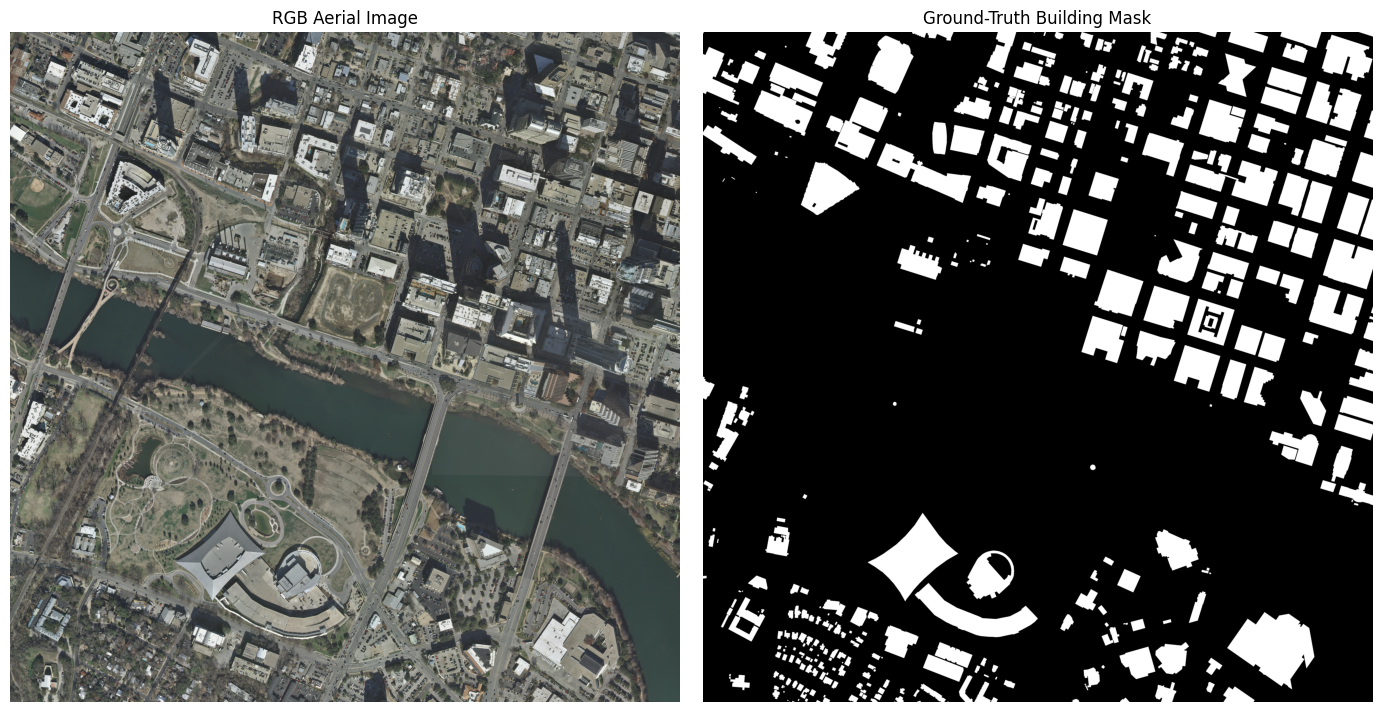

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

sample = train_df.iloc[0]

image = np.array(Image.open(sample["image"]).convert("RGB"))
mask = np.array(Image.open(sample["mask"]).convert("L"))

print("City:", sample["city"])
print("Tile:", sample["tile"])
print("Image shape:", image.shape)
print("Mask shape:", mask.shape)
print("Image dtype:", image.dtype)
print("Mask unique values:", np.unique(mask))

fig, ax = plt.subplots(1, 2, figsize=(14, 7))

ax[0].imshow(image)
ax[0].set_title("RGB Aerial Image")
ax[0].axis("off")

ax[1].imshow(mask, cmap="gray")
ax[1].set_title("Ground-Truth Building Mask")
ax[1].axis("off")

plt.tight_layout()
plt.show()

###Check class imbalance

In [ ]:
building_fractions = []

for mask_path in train_df["mask"]:
    mask_img = Image.open(mask_path).convert("L")

    # Downsample only for this quick statistical calculation
    mask_img.thumbnail((500, 500))

    mask_array = np.array(mask_img)
    binary_mask = mask_array > 127

    building_fractions.append(binary_mask.mean())

mean_building_fraction = np.mean(building_fractions)

print(f"Average building fraction: {mean_building_fraction:.3f}")
print(f"Average background fraction: {1 - mean_building_fraction:.3f}")

Average building fraction: 0.181
Average background fraction: 0.819


## 3. Model, Loss, and Metrics

With the data partitioned and verified, the next step is defining the modeling components: a pretrained segmentation architecture, a loss function suited to imbalanced binary masks, and evaluation metrics that go beyond pixel accuracy. `segmentation_models_pytorch` provides a ready-made U-Net with swappable pretrained encoders, avoiding the need to hand-write and separately validate a U-Net implementation.

In [ ]:
!pip -q install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 2.7 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


###Create 512 × 512 training patches dynamically

In [ ]:
import random

PATCH_SIZE = 512

class BuildingPatchDataset(Dataset):

    def __init__(
        self,
        dataframe,
        samples_per_epoch,
        patch_size=512,
        augment=False
    ):

        self.df = dataframe.reset_index(drop=True)
        self.samples_per_epoch = samples_per_epoch
        self.patch_size = patch_size
        self.augment = augment

    def __len__(self):
        return self.samples_per_epoch

    def __getitem__(self, idx):

        # Randomly choose one complete tile
        row = self.df.sample(1).iloc[0]

        image = np.array(
            Image.open(row["image"]).convert("RGB")
        )

        mask = np.array(
            Image.open(row["mask"]).convert("L")
        )

        H, W = image.shape[:2]
        p = self.patch_size

        # Random crop location
        y = random.randint(0, H - p)
        x = random.randint(0, W - p)

        image = image[y:y+p, x:x+p]
        mask = mask[y:y+p, x:x+p]

        # Binary ground truth
        mask = (mask > 127).astype(np.float32)

        # Basic augmentation
        if self.augment:

            if random.random() < 0.5:
                image = np.fliplr(image).copy()
                mask = np.fliplr(mask).copy()

            if random.random() < 0.5:
                image = np.flipud(image).copy()
                mask = np.flipud(mask).copy()

            k = random.randint(0, 3)

            image = np.rot90(image, k).copy()
            mask = np.rot90(mask, k).copy()

        # Scale RGB to 0–1
        image = image.astype(np.float32) / 255.0

        # ImageNet normalization for pretrained ResNet
        mean = np.array(
            [0.485, 0.456, 0.406],
            dtype=np.float32
        )

        std = np.array(
            [0.229, 0.224, 0.225],
            dtype=np.float32
        )

        image = (image - mean) / std

        image = torch.from_numpy(
            image.transpose(2, 0, 1)
        ).float()

        mask = torch.from_numpy(
            mask[None, :, :]
        ).float()

        return image, mask

###Create Data Loaders

In [ ]:
train_dataset = BuildingPatchDataset(
    train_df,
    samples_per_epoch=1200,
    patch_size=512,
    augment=True
)

val_dataset = BuildingPatchDataset(
    val_df,
    samples_per_epoch=300,
    patch_size=512,
    augment=False
)

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

Test it:

In [ ]:
images, masks = next(iter(train_loader))

print("Images:", images.shape)
print("Masks :", masks.shape)

Images: torch.Size([4, 3, 512, 512])
Masks : torch.Size([4, 1, 512, 512])


### Building the Segmentation Model

With the data pipeline in place, the next step is defining the network itself.


###Build U-Net

In [ ]:
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
)

model = model.to(device)

print(
    "Trainable parameters:",
    f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}"
)

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 87.3MB            

model.safetensors: downloading bytes:           |  0.00B            

Trainable parameters: 24,436,369


Why U-Net + ResNet34?
Put this Markdown cell above it:
### Model Architecture

A U-Net architecture with a pretrained ResNet34 encoder was selected for
binary building-footprint segmentation. U-Net combines high-level contextual
features from the encoder with fine spatial information transferred through
skip connections to the decoder. This is particularly useful for building
segmentation, where both object recognition and accurate spatial boundaries
are important.

ImageNet-pretrained ResNet34 weights were used to provide transferable
low-level visual features while maintaining a model size suitable for the
available Colab GPU resources.

BCE + Dice loss
### Loss Function

Binary cross-entropy (BCE) and Dice loss are combined during training.

BCE provides pixel-wise binary classification supervision, whereas Dice loss
directly encourages overlap between predicted and ground-truth building
regions. Dice loss is particularly useful when foreground building pixels and
background pixels are imbalanced.

The combined objective therefore considers both pixel-level classification
and region-level segmentation quality.

In [ ]:
bce_loss = nn.BCEWithLogitsLoss()

def dice_loss(logits, targets, smooth=1e-7):

    probabilities = torch.sigmoid(logits)

    intersection = (
        probabilities * targets
    ).sum(dim=(1, 2, 3))

    denominator = (
        probabilities.sum(dim=(1, 2, 3))
        + targets.sum(dim=(1, 2, 3))
    )

    dice = (
        2 * intersection + smooth
    ) / (
        denominator + smooth
    )

    return 1 - dice.mean()


def combined_loss(logits, targets):

    return (
        bce_loss(logits, targets)
        + dice_loss(logits, targets)
    )

### Evaluation Metrics


For this task, IoU and Dice matter far more than raw pixel accuracy: because buildings are a minority class, a model that predicts "background everywhere" would already score high on accuracy while being completely useless (IoU = 0). Precision and recall are tracked alongside IoU/Dice specifically so that, later, *which* kind of error the model tends to make (missed buildings vs. over-predicted building area) can be diagnosed rather than hidden inside a single summary number.

In [ ]:
def calculate_metrics(logits, targets, threshold=0.5):

    probabilities = torch.sigmoid(logits)

    predictions = probabilities > threshold
    targets = targets > 0.5

    TP = (predictions & targets).sum().item()
    FP = (predictions & ~targets).sum().item()
    FN = (~predictions & targets).sum().item()
    TN = (~predictions & ~targets).sum().item()

    eps = 1e-8

    iou = TP / (TP + FP + FN + eps)

    dice = (
        2 * TP
        / (2 * TP + FP + FN + eps)
    )

    precision = TP / (TP + FP + eps)

    recall = TP / (TP + FN + eps)

    accuracy = (
        (TP + TN)
        / (TP + TN + FP + FN + eps)
    )

    return {
        "IoU": iou,
        "Dice": dice,
        "Precision": precision,
        "Recall": recall,
        "Accuracy": accuracy
    }

###Optimizer

In [ ]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

## 4. Training

With the model, loss, and metrics defined, this section wires them into the actual training and validation loops — one epoch of gradient updates on the training set, followed by a no-gradient pass over the validation set that also accumulates the confusion-matrix counts needed for IoU/Dice/Precision/Recall.

In [ ]:
def train_one_epoch(model, loader):

    model.train()

    running_loss = 0

    for images, masks in loader:

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        logits = model(images)

        loss = combined_loss(
            logits,
            masks
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(loader)

###Validation

In [ ]:
@torch.no_grad()
def validate(model, loader):

    model.eval()

    running_loss = 0

    TP = FP = FN = TN = 0

    for images, masks in loader:

        images = images.to(device)
        masks = masks.to(device)

        logits = model(images)

        loss = combined_loss(
            logits,
            masks
        )

        running_loss += loss.item()

        predictions = (
            torch.sigmoid(logits) > 0.5
        )

        targets = masks > 0.5

        TP += (predictions & targets).sum().item()
        FP += (predictions & ~targets).sum().item()
        FN += (~predictions & targets).sum().item()
        TN += (~predictions & ~targets).sum().item()

    eps = 1e-8

    metrics = {
        "IoU":
            TP / (TP + FP + FN + eps),

        "Dice":
            2 * TP / (2 * TP + FP + FN + eps),

        "Precision":
            TP / (TP + FP + eps),

        "Recall":
            TP / (TP + FN + eps),

        "Accuracy":
            (TP + TN)
            / (TP + TN + FP + FN + eps)
    }

    return (
        running_loss / len(loader),
        metrics
    )

###Save results to Drive

In [ ]:
from pathlib import Path

output_dir = Path(
    "/content/drive/MyDrive/InriaDataset/Part2_Results"
)

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

best_model_path = (
    output_dir / "best_unet_resnet34.pth"
)

print(output_dir)

/content/drive/MyDrive/InriaDataset/Part2_Results


###Train

In [ ]:
EPOCHS = 15
PATIENCE = 4

history = []

best_iou = 0
epochs_without_improvement = 0

for epoch in range(1, EPOCHS + 1):

    train_loss = train_one_epoch(
        model,
        train_loader
    )

    val_loss, val_metrics = validate(
        model,
        val_loader
    )

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"IoU: {val_metrics['IoU']:.4f} | "
        f"Dice: {val_metrics['Dice']:.4f} | "
        f"Precision: {val_metrics['Precision']:.4f} | "
        f"Recall: {val_metrics['Recall']:.4f}"
    )

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        **val_metrics
    })

    if val_metrics["IoU"] > best_iou:

        best_iou = val_metrics["IoU"]

        epochs_without_improvement = 0

        torch.save(
            model.state_dict(),
            best_model_path
        )

        print("Best model saved.")

    else:

        epochs_without_improvement += 1

        if epochs_without_improvement >= PATIENCE:

            print("Early stopping.")
            break

Epoch 01 | Train Loss: 0.9306 | Val Loss: 0.6939 | IoU: 0.6456 | Dice: 0.7847 | Precision: 0.7982 | Recall: 0.7716
Best model saved.
Epoch 02 | Train Loss: 0.7073 | Val Loss: 0.5779 | IoU: 0.7023 | Dice: 0.8251 | Precision: 0.8393 | Recall: 0.8113
Best model saved.
Epoch 03 | Train Loss: 0.6441 | Val Loss: 0.5853 | IoU: 0.6980 | Dice: 0.8221 | Precision: 0.8394 | Recall: 0.8056
Epoch 04 | Train Loss: 0.5982 | Val Loss: 0.5333 | IoU: 0.7176 | Dice: 0.8356 | Precision: 0.8106 | Recall: 0.8622
Best model saved.
Epoch 05 | Train Loss: 0.5886 | Val Loss: 0.5266 | IoU: 0.7296 | Dice: 0.8436 | Precision: 0.8440 | Recall: 0.8433
Best model saved.
Epoch 06 | Train Loss: 0.5660 | Val Loss: 0.5383 | IoU: 0.7093 | Dice: 0.8299 | Precision: 0.8314 | Recall: 0.8285
Epoch 07 | Train Loss: 0.5550 | Val Loss: 0.5351 | IoU: 0.7207 | Dice: 0.8377 | Precision: 0.8460 | Recall: 0.8295
Epoch 08 | Train Loss: 0.5582 | Val Loss: 0.5098 | IoU: 0.7337 | Dice: 0.8464 | Precision: 0.8377 | Recall: 0.8553
Best mod

## 5. Loading the Best Checkpoint




In [ ]:
import os
import torch

BEST_MODEL_PATH = "/content/drive/MyDrive/InriaDataset/Part2_Results/best_unet_resnet34.pth"

if not os.path.exists(BEST_MODEL_PATH):
    raise FileNotFoundError(f"Checkpoint not found: {BEST_MODEL_PATH}")

# Load the checkpoint with the best validation IoU
state_dict = torch.load(
    BEST_MODEL_PATH,
    map_location=device,
    weights_only=True
)

model.load_state_dict(state_dict)
model = model.to(device)
model.eval()

print("Best model loaded successfully.")
print("Checkpoint:", BEST_MODEL_PATH)
print("Device:", device)

Best model loaded successfully.
Checkpoint: /content/drive/MyDrive/InriaDataset/Part2_Results/best_unet_resnet34.pth
Device: cuda


Verify the held-out Tyrol test set

In [ ]:
# Verify the held-out Tyrol test set

import pandas as pd

print("Test tiles:", len(test_df))

print("\nCities in test set:")
print(test_df["city"].value_counts())

print("\nFirst few test tiles:")
display(test_df.head())


# Leakage checks
# Use 'tile' because this is the unique tile identifier
# in our split DataFrames.

train_tiles = set(train_df["tile"])
val_tiles   = set(val_df["tile"])
test_tiles  = set(test_df["tile"])


# Check that no source tile occurs in more than one split
assert train_tiles.isdisjoint(test_tiles), \
    "ERROR: Train/test tile leakage detected!"

assert val_tiles.isdisjoint(test_tiles), \
    "ERROR: Validation/test tile leakage detected!"

assert train_tiles.isdisjoint(val_tiles), \
    "ERROR: Train/validation tile leakage detected!"


# Verify geographic holdout

test_cities = set(test_df["city"].str.lower())

assert test_cities == {"tyrol"}, \
    f"ERROR: Expected only Tyrol in test set, found: {test_cities}"


# Verify image and mask paths are unique

assert test_df["image"].is_unique, \
    "ERROR: Duplicate test image paths detected!"

assert test_df["mask"].is_unique, \
    "ERROR: Duplicate test mask paths detected!"


# Final summary

print("\n" + "=" * 60)
print("TEST SET VERIFICATION PASSED")
print("=" * 60)

print(f"Training tiles   : {len(train_df)}")
print(f"Validation tiles : {len(val_df)}")
print(f"Test tiles       : {len(test_df)}")

print("\nTest city:", sorted(test_cities))

print("\n✓ No tile overlap between training and validation.")
print("✓ No tile overlap between training and test.")
print("✓ No tile overlap between validation and test.")
print("✓ All 36 test tiles are from held-out Tyrol.")
print("✓ Test image paths are unique.")
print("✓ Test mask paths are unique.")

print("\nGeographic holdout is ready for final evaluation.")

Test tiles: 36

Cities in test set:
city
tyrol    36
Name: count, dtype: int64

First few test tiles:


,city,tile,image,mask
108,tyrol,tyrol-w1,/content/drive/MyDrive/InriaDataset/extracted/...,/content/drive/MyDrive/InriaDataset/extracted/...
109,tyrol,tyrol-w10,/content/drive/MyDrive/InriaDataset/extracted/...,/content/drive/MyDrive/InriaDataset/extracted/...
110,tyrol,tyrol-w11,/content/drive/MyDrive/InriaDataset/extracted/...,/content/drive/MyDrive/InriaDataset/extracted/...
111,tyrol,tyrol-w12,/content/drive/MyDrive/InriaDataset/extracted/...,/content/drive/MyDrive/InriaDataset/extracted/...
112,tyrol,tyrol-w13,/content/drive/MyDrive/InriaDataset/extracted/...,/content/drive/MyDrive/InriaDataset/extracted/...



TEST SET VERIFICATION PASSED
Training tiles   : 116
Validation tiles : 28
Test tiles       : 36

Test city: ['tyrol']

✓ No tile overlap between training and validation.
✓ No tile overlap between training and test.
✓ No tile overlap between validation and test.
✓ All 36 test tiles are from held-out Tyrol.
✓ Test image paths are unique.
✓ Test mask paths are unique.

Geographic holdout is ready for final evaluation.


## 6. Full-Resolution Inference and a Single-Tile Diagnostic


The segmentation model was trained on 512×512 patches, whereas each original Inria tile is 5000×5000 pixels. Resizing an entire tile down to 512×512 for inference would destroy small-building and boundary detail — exactly the detail this task cares about.

Instead, each held-out image is evaluated using a **sliding window** of overlapping 512×512 patches (384px stride). Predictions from overlapping regions are averaged back together to reconstruct one full-resolution probability map. This evaluates the model at deployment scale — on the same full tiles a real system would receive — while the overlap smooths away patch-boundary artifacts that a naive non-overlapping tiling would leave behind.

In [ ]:
# Full-resolution tiled inference

import numpy as np
import torch
from PIL import Image

# Same normalization used during training
IMAGENET_MEAN = np.array(
    [0.485, 0.456, 0.406],
    dtype=np.float32
)

IMAGENET_STD = np.array(
    [0.229, 0.224, 0.225],
    dtype=np.float32
)


def get_start_positions(length, patch_size, stride):
    """
    Generate patch starting positions while ensuring that
    the final patch reaches the image boundary.
    """
    positions = list(
        range(0, max(length - patch_size + 1, 1), stride)
    )

    last_position = max(length - patch_size, 0)

    if len(positions) == 0 or positions[-1] != last_position:
        positions.append(last_position)

    return positions


@torch.no_grad()
def predict_full_tile(
    model,
    image_path,
    device,
    patch_size=512,
    stride=384,
    batch_size=8
):
    """
    Predict a full-resolution segmentation probability map
    using overlapping image patches.

    Overlapping predictions are averaged.
    """

    # Load RGB image
    image = np.array(
        Image.open(image_path).convert("RGB"),
        dtype=np.float32
    ) / 255.0

    H, W, _ = image.shape

    # Determine patch locations
    y_positions = get_start_positions(
        H, patch_size, stride
    )

    x_positions = get_start_positions(
        W, patch_size, stride
    )

    coordinates = [
        (y, x)
        for y in y_positions
        for x in x_positions
    ]

    # Full-resolution accumulation arrays
    probability_sum = np.zeros(
        (H, W),
        dtype=np.float32
    )

    prediction_count = np.zeros(
        (H, W),
        dtype=np.float32
    )

    model.eval()

    # Process patches in batches
    for start in range(
        0,
        len(coordinates),
        batch_size
    ):

        batch_coordinates = coordinates[
            start:start + batch_size
        ]

        batch_patches = []

        for y, x in batch_coordinates:

            patch = image[
                y:y + patch_size,
                x:x + patch_size
            ]

            # ImageNet normalization
            patch = (
                patch - IMAGENET_MEAN
            ) / IMAGENET_STD

            # HWC -> CHW
            patch = np.transpose(
                patch,
                (2, 0, 1)
            )

            batch_patches.append(patch)

        batch_tensor = torch.from_numpy(
            np.stack(batch_patches)
        ).float().to(device)

        # Model prediction
        logits = model(batch_tensor)

        probabilities = torch.sigmoid(
            logits
        ).squeeze(1)

        probabilities = (
            probabilities
            .cpu()
            .numpy()
        )

        # Add predictions back to full image
        for probability, (y, x) in zip(
            probabilities,
            batch_coordinates
        ):

            probability_sum[
                y:y + patch_size,
                x:x + patch_size
            ] += probability

            prediction_count[
                y:y + patch_size,
                x:x + patch_size
            ] += 1.0

    # Safety check
    assert np.all(prediction_count > 0), \
        "Some pixels were not covered during tiled inference."

    # Average overlapping predictions
    full_probability = (
        probability_sum /
        prediction_count
    )

    return full_probability

###Test it on one Tyrol image first

In [ ]:
# Test inference on one held-out Tyrol tile

import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import time

sample = test_df.iloc[0]

print("Testing tile:", sample["tile"])
print("Image:", sample["image"])

start_time = time.time()

prob_map = predict_full_tile(
    model=model,
    image_path=sample["image"],
    device=device,
    patch_size=512,
    stride=384,
    batch_size=8
)

elapsed = time.time() - start_time

# Convert probability map to binary prediction
pred_mask = (prob_map >= 0.5).astype(np.uint8)

# Load ground-truth mask
gt_mask = np.array(
    Image.open(sample["mask"]).convert("L")
)

gt_mask = (gt_mask > 127).astype(np.uint8)

print("\nFull prediction shape:", prob_map.shape)
print("Ground-truth shape:", gt_mask.shape)

print(
    "Probability range:",
    f"{prob_map.min():.4f}",
    "to",
    f"{prob_map.max():.4f}"
)

print(
    "Predicted building fraction:",
    f"{pred_mask.mean():.4f}"
)

print(
    "Ground-truth building fraction:",
    f"{gt_mask.mean():.4f}"
)

print(
    "Inference time:",
    f"{elapsed:.1f} seconds"
)

Testing tile: tyrol-w1
Image: /content/drive/MyDrive/InriaDataset/extracted/Inria_Aerial_Dataset/AerialImageDataset/train/images/tyrol-w1.tif

Full prediction shape: (5000, 5000)
Ground-truth shape: (5000, 5000)
Probability range: 0.0000 to 0.9983
Predicted building fraction: 0.0952
Ground-truth building fraction: 0.0698
Inference time: 5.7 seconds


### Quantitative evaluation on the held-out test image

Segmentation performance is evaluated using IoU, Dice coefficient, precision, and recall rather than pixel accuracy alone. Pixel accuracy can be misleading for building segmentation because background pixels occupy a large fraction of each aerial image — a model could score well on accuracy while badly under- or over-predicting buildings.

IoU and Dice measure the spatial overlap between the predicted and ground-truth building masks. Precision measures how much of the *predicted* building area is actually building; recall measures how much of the *true* building area was successfully detected. Reporting all four together, rather than any one alone, is what makes it possible to tell apart "the model over-predicts" from "the model under-predicts" — both of which a single overlap number would hide.

In [ ]:
# Metrics for first held-out Tyrol tile

import numpy as np


def calculate_segmentation_metrics(pred, gt):
    """
    Calculate binary segmentation metrics from full-resolution masks.

    pred and gt must contain 0/1 values.
    """

    pred = pred.astype(bool)
    gt = gt.astype(bool)

    TP = np.logical_and(pred, gt).sum()
    FP = np.logical_and(pred, ~gt).sum()
    FN = np.logical_and(~pred, gt).sum()
    TN = np.logical_and(~pred, ~gt).sum()

    eps = 1e-7

    iou = TP / (TP + FP + FN + eps)

    dice = (2 * TP) / (
        2 * TP + FP + FN + eps
    )

    precision = TP / (
        TP + FP + eps
    )

    recall = TP / (
        TP + FN + eps
    )

    accuracy = (
        TP + TN
    ) / (
        TP + TN + FP + FN + eps
    )

    return {
        "IoU": iou,
        "Dice": dice,
        "Precision": precision,
        "Recall": recall,
        "Accuracy": accuracy,
        "TP": int(TP),
        "FP": int(FP),
        "FN": int(FN),
        "TN": int(TN)
    }


metrics = calculate_segmentation_metrics(
    pred_mask,
    gt_mask
)

print("=" * 55)
print("TEST METRICS —", sample["tile"])
print("=" * 55)

print(f"IoU       : {metrics['IoU']:.4f}")
print(f"Dice      : {metrics['Dice']:.4f}")
print(f"Precision : {metrics['Precision']:.4f}")
print(f"Recall    : {metrics['Recall']:.4f}")
print(f"Accuracy  : {metrics['Accuracy']:.4f}")

print("\nPixel counts:")
print(f"TP : {metrics['TP']:,}")
print(f"FP : {metrics['FP']:,}")
print(f"FN : {metrics['FN']:,}")
print(f"TN : {metrics['TN']:,}")

TEST METRICS — tyrol-w1
IoU       : 0.6055
Dice      : 0.7543
Precision : 0.6535
Recall    : 0.8919
Accuracy  : 0.9595

Pixel counts:
TP : 1,555,818
FP : 824,930
FN : 188,649
TN : 22,430,603


###Actually look at the prediction



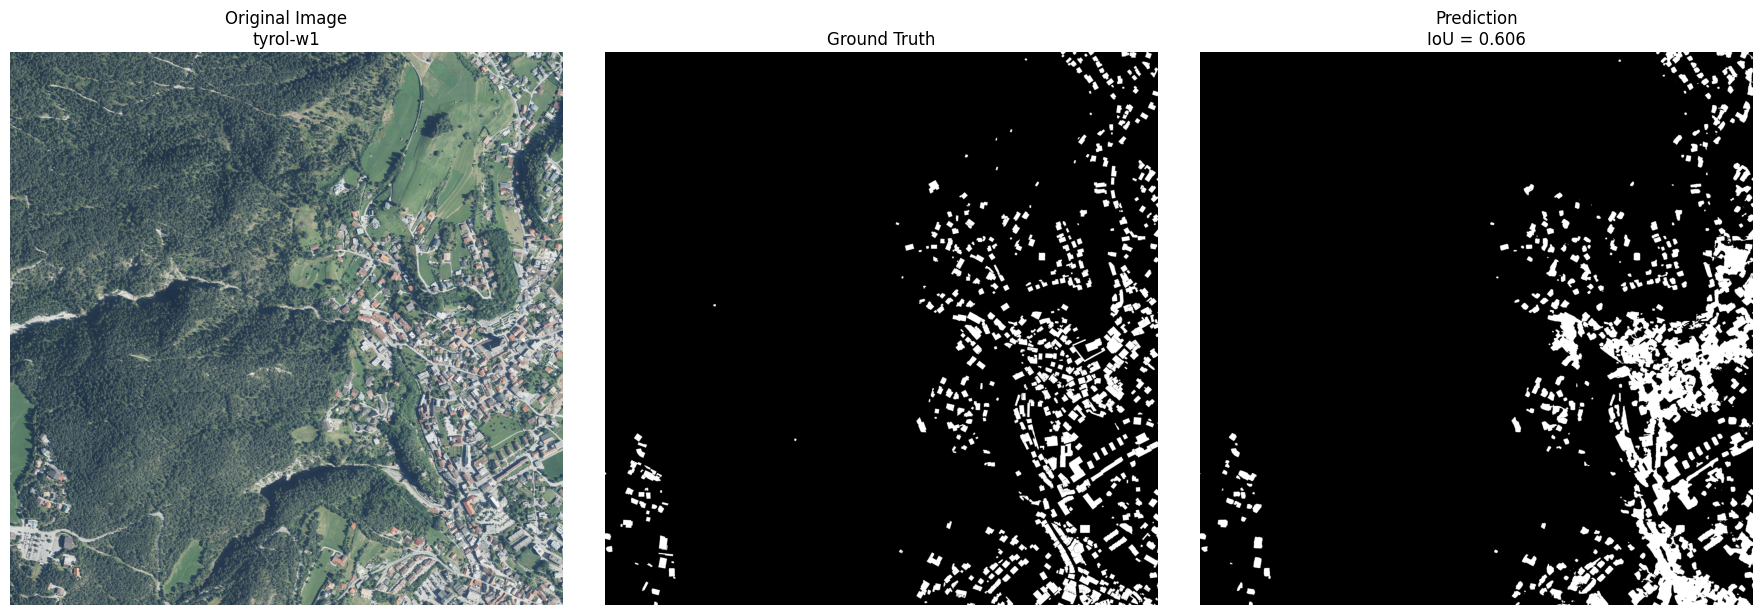

In [ ]:
# Visual inspection of first held-out prediction

import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

original_image = np.array(
    Image.open(sample["image"]).convert("RGB")
)

fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 6)
)

axes[0].imshow(original_image)
axes[0].set_title(
    f"Original Image\n{sample['tile']}"
)
axes[0].axis("off")

axes[1].imshow(
    gt_mask,
    cmap="gray"
)
axes[1].set_title("Ground Truth")
axes[1].axis("off")

axes[2].imshow(
    pred_mask,
    cmap="gray"
)
axes[2].set_title(
    f"Prediction\nIoU = {metrics['IoU']:.3f}"
)
axes[2].axis("off")

plt.tight_layout()
plt.show()

### Interpreting the first result

For tyrol-w1, the model reached IoU = 0.6055, Dice = 0.7543, Precision = 0.6535, Recall = 0.8919, Accuracy = 0.9595. The high recall paired with the noticeably lower precision matches the visualization directly: the model detects most of the real buildings, but in the dense urban area on the right/lower-right of the tile it predicts too much connected building area. This tile therefore shows **over-segmentation / false positives**, not primarily missed buildings.

The high pixel accuracy is also a useful illustration of why accuracy alone is inadequate here — the large background area makes 95.95% accuracy look excellent despite only 0.606 IoU, i.e. a model that is meaningfully imperfect at the actual task of interest.

Before drawing any general conclusion, though, this is only one tile — the next step evaluates all 36 held-out Tyrol tiles to see whether this pattern holds generally or was mostly a property of this particular scene.


## 7. Evaluation on the Complete Held-Out Test Set



In [ ]:
# Evaluate all 36 held-out Tyrol tiles

import os
import time
import numpy as np
import pandas as pd
from PIL import Image

RESULTS_DIR = "/content/drive/MyDrive/InriaDataset/Part2_Results"
os.makedirs(RESULTS_DIR, exist_ok=True)

all_results = []

# Global confusion counts
global_TP = 0
global_FP = 0
global_FN = 0
global_TN = 0

total_start = time.time()

print("=" * 70)
print("FINAL EVALUATION — HELD-OUT TYROL TEST SET")
print("=" * 70)
print(f"Number of test tiles: {len(test_df)}\n")


for i, (_, row) in enumerate(test_df.iterrows(), start=1):

    tile_name = row["tile"]

    start = time.time()

    # Full-resolution prediction
    probability_map = predict_full_tile(
        model=model,
        image_path=row["image"],
        device=device,
        patch_size=512,
        stride=384,
        batch_size=8
    )

    # Binary prediction using threshold = 0.5
    prediction = (
        probability_map >= 0.5
    ).astype(np.uint8)

    # Load ground-truth mask
    ground_truth = np.array(
        Image.open(row["mask"]).convert("L")
    )

    ground_truth = (
        ground_truth > 127
    ).astype(np.uint8)

    # Safety check
    assert prediction.shape == ground_truth.shape, \
        f"Shape mismatch for {tile_name}"

    # Calculate metrics
    m = calculate_segmentation_metrics(
        prediction,
        ground_truth
    )

    elapsed = time.time() - start

    # Building fractions
    predicted_fraction = prediction.mean()
    true_fraction = ground_truth.mean()

    all_results.append({
        "tile": tile_name,
        "IoU": m["IoU"],
        "Dice": m["Dice"],
        "Precision": m["Precision"],
        "Recall": m["Recall"],
        "Accuracy": m["Accuracy"],
        "GT_building_fraction": true_fraction,
        "Pred_building_fraction": predicted_fraction,
        "TP": m["TP"],
        "FP": m["FP"],
        "FN": m["FN"],
        "TN": m["TN"],
        "Inference_seconds": elapsed
    })

    # Add to global confusion counts
    global_TP += m["TP"]
    global_FP += m["FP"]
    global_FN += m["FN"]
    global_TN += m["TN"]

    print(
        f"[{i:02d}/{len(test_df)}] "
        f"{tile_name:12s} | "
        f"IoU {m['IoU']:.4f} | "
        f"Dice {m['Dice']:.4f} | "
        f"P {m['Precision']:.4f} | "
        f"R {m['Recall']:.4f} | "
        f"{elapsed:.1f}s"
    )


# Convert results to DataFrame

results_df = pd.DataFrame(all_results)


# Global metrics from ALL pixels

eps = 1e-7

global_iou = (
    global_TP /
    (global_TP + global_FP + global_FN + eps)
)

global_dice = (
    2 * global_TP /
    (2 * global_TP + global_FP + global_FN + eps)
)

global_precision = (
    global_TP /
    (global_TP + global_FP + eps)
)

global_recall = (
    global_TP /
    (global_TP + global_FN + eps)
)

global_accuracy = (
    (global_TP + global_TN) /
    (global_TP + global_FP + global_FN + global_TN + eps)
)


# Per-tile mean and standard deviation

metric_columns = [
    "IoU",
    "Dice",
    "Precision",
    "Recall",
    "Accuracy"
]

mean_metrics = results_df[metric_columns].mean()
std_metrics = results_df[metric_columns].std()


# Print final summary

total_elapsed = time.time() - total_start

print("\n" + "=" * 70)
print("HELD-OUT TYROL TEST RESULTS")
print("=" * 70)

print("\nGLOBAL PIXEL-AGGREGATED METRICS")
print("-" * 45)

print(f"IoU       : {global_iou:.4f}")
print(f"Dice      : {global_dice:.4f}")
print(f"Precision : {global_precision:.4f}")
print(f"Recall    : {global_recall:.4f}")
print(f"Accuracy  : {global_accuracy:.4f}")


print("\nPER-TILE MEAN ± STANDARD DEVIATION")
print("-" * 45)

for metric in metric_columns:

    print(
        f"{metric:9s}: "
        f"{mean_metrics[metric]:.4f} "
        f"± {std_metrics[metric]:.4f}"
    )


print("\nBEST / WORST IoU")
print("-" * 45)

best_row = results_df.loc[
    results_df["IoU"].idxmax()
]

worst_row = results_df.loc[
    results_df["IoU"].idxmin()
]

print(
    f"Best  : {best_row['tile']} "
    f"| IoU = {best_row['IoU']:.4f} "
    f"| Dice = {best_row['Dice']:.4f}"
)

print(
    f"Worst : {worst_row['tile']} "
    f"| IoU = {worst_row['IoU']:.4f} "
    f"| Dice = {worst_row['Dice']:.4f}"
)

print(
    f"\nTotal evaluation time: "
    f"{total_elapsed / 60:.2f} minutes"
)


# Save results

csv_path = os.path.join(
    RESULTS_DIR,
    "tyrol_test_per_tile_metrics.csv"
)

results_df.to_csv(
    csv_path,
    index=False
)


summary_df = pd.DataFrame({
    "Metric": [
        "IoU",
        "Dice",
        "Precision",
        "Recall",
        "Accuracy"
    ],

    "Global": [
        global_iou,
        global_dice,
        global_precision,
        global_recall,
        global_accuracy
    ],

    "Per_tile_mean": [
        mean_metrics["IoU"],
        mean_metrics["Dice"],
        mean_metrics["Precision"],
        mean_metrics["Recall"],
        mean_metrics["Accuracy"]
    ],

    "Per_tile_std": [
        std_metrics["IoU"],
        std_metrics["Dice"],
        std_metrics["Precision"],
        std_metrics["Recall"],
        std_metrics["Accuracy"]
    ]
})


summary_path = os.path.join(
    RESULTS_DIR,
    "tyrol_test_summary.csv"
)

summary_df.to_csv(
    summary_path,
    index=False
)


print("\nResults saved:")
print(csv_path)
print(summary_path)

print("\n✓ Final evaluation complete.")

FINAL EVALUATION — HELD-OUT TYROL TEST SET
Number of test tiles: 36

[01/36] tyrol-w1     | IoU 0.6055 | Dice 0.7543 | P 0.6535 | R 0.8919 | 5.9s
[02/36] tyrol-w10    | IoU 0.6732 | Dice 0.8047 | P 0.7398 | R 0.8822 | 5.7s
[03/36] tyrol-w11    | IoU 0.6022 | Dice 0.7517 | P 0.6520 | R 0.8874 | 5.7s
[04/36] tyrol-w12    | IoU 0.6287 | Dice 0.7720 | P 0.6782 | R 0.8959 | 5.9s
[05/36] tyrol-w13    | IoU 0.6449 | Dice 0.7841 | P 0.7238 | R 0.8554 | 5.5s
[06/36] tyrol-w14    | IoU 0.6294 | Dice 0.7725 | P 0.7018 | R 0.8591 | 6.1s
[07/36] tyrol-w15    | IoU 0.6580 | Dice 0.7938 | P 0.7241 | R 0.8782 | 5.8s
[08/36] tyrol-w16    | IoU 0.5945 | Dice 0.7457 | P 0.6953 | R 0.8039 | 6.1s
[09/36] tyrol-w17    | IoU 0.7342 | Dice 0.8467 | P 0.8078 | R 0.8897 | 5.9s
[10/36] tyrol-w18    | IoU 0.6494 | Dice 0.7874 | P 0.6979 | R 0.9033 | 5.9s
[11/36] tyrol-w19    | IoU 0.8029 | Dice 0.8907 | P 0.8932 | R 0.8881 | 6.1s
[12/36] tyrol-w2     | IoU 0.5672 | Dice 0.7239 | P 0.6129 | R 0.8838 | 5.4s
[13/36]

### Qualitative evaluation of representative test cases



Selected qualitative cases:
Best           : tyrol-w19    | IoU = 0.8029
Representative : tyrol-w32    | IoU = 0.7038
Worst          : tyrol-w2     | IoU = 0.5672

Processing best case: tyrol-w19


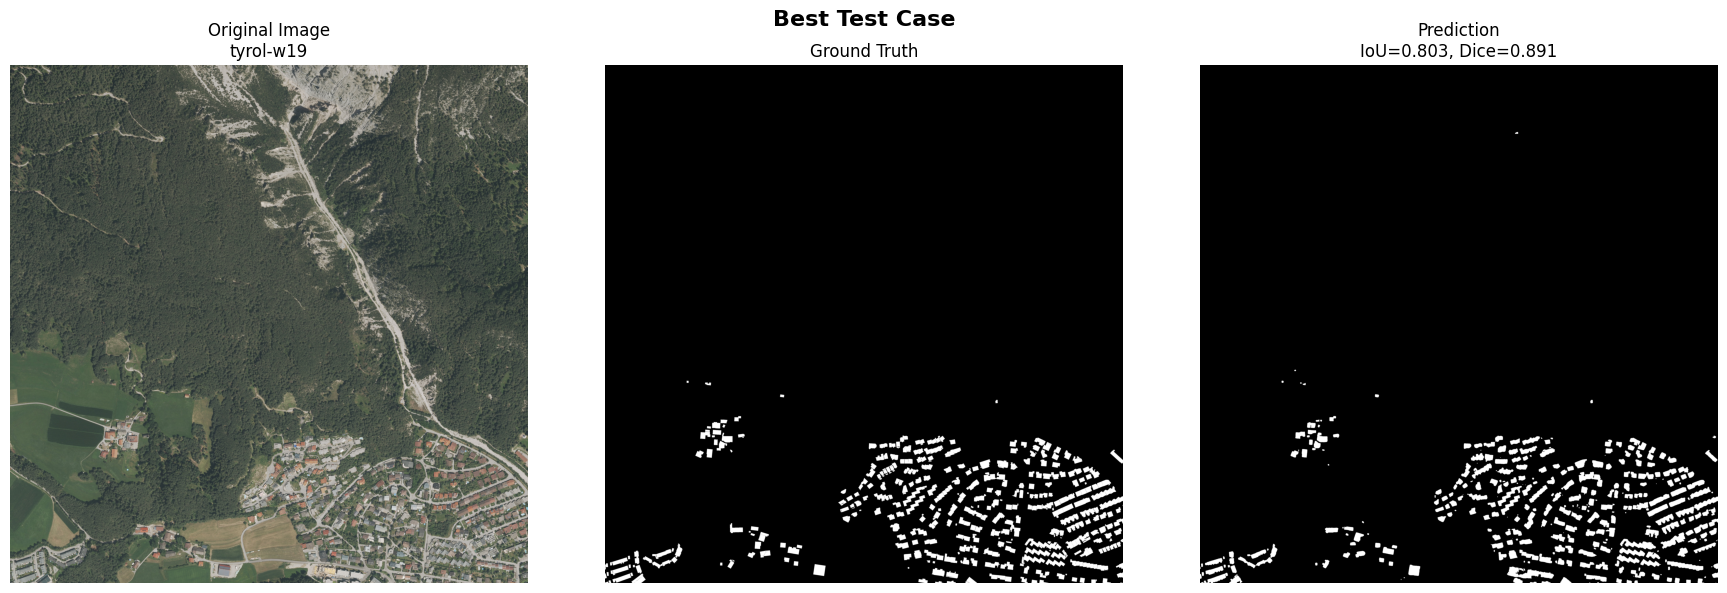

Saved: /content/drive/MyDrive/InriaDataset/Part2_Results/best_tyrol-w19_comparison.png

Processing representative case: tyrol-w32


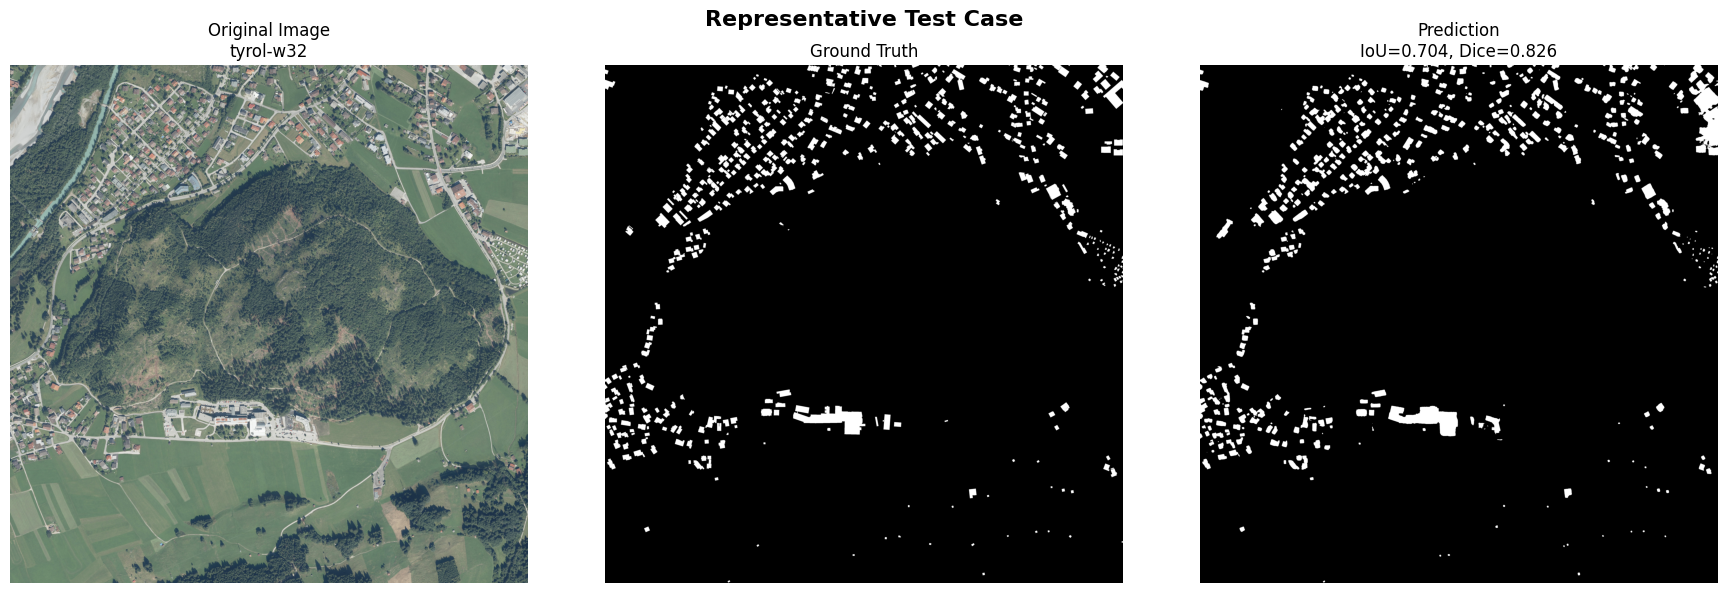

Saved: /content/drive/MyDrive/InriaDataset/Part2_Results/representative_tyrol-w32_comparison.png

Processing worst case: tyrol-w2


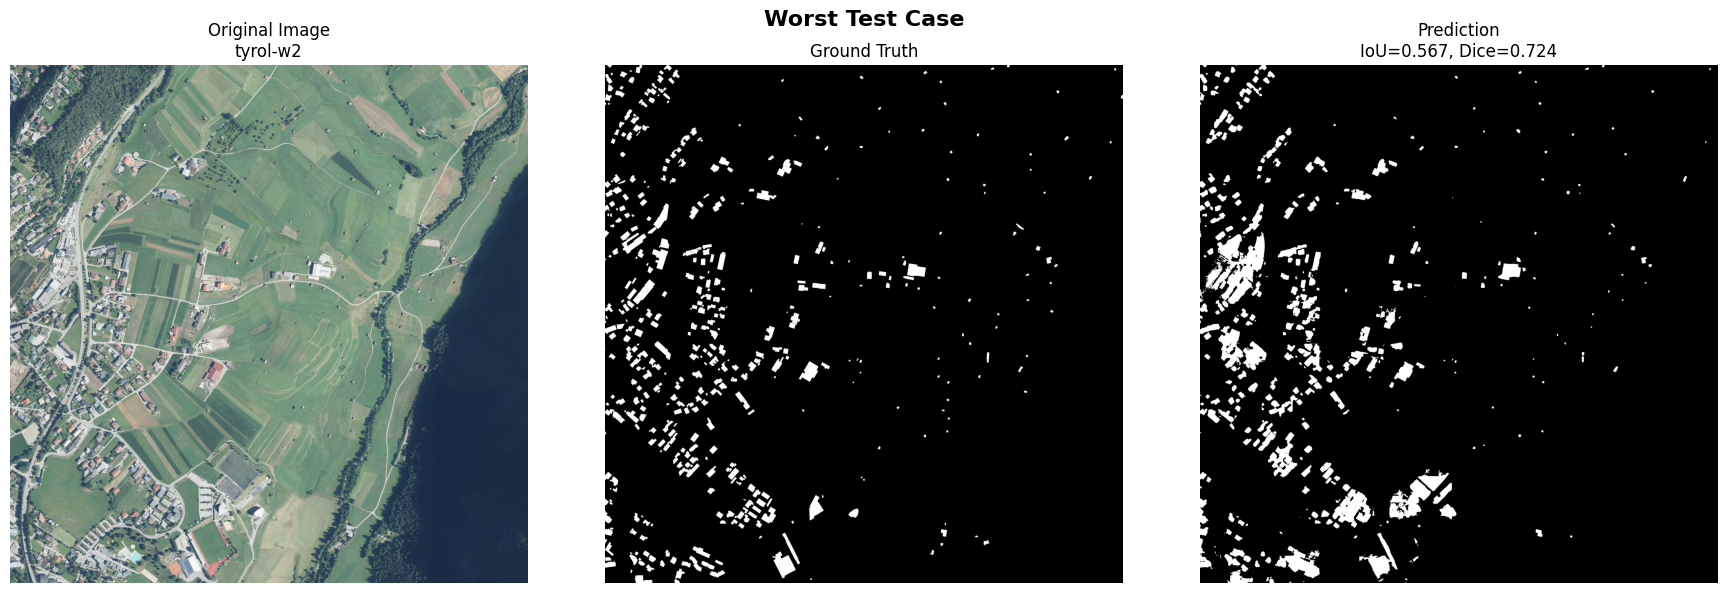

Saved: /content/drive/MyDrive/InriaDataset/Part2_Results/worst_tyrol-w2_comparison.png


In [ ]:
# Best, representative, and worst qualitative cases

import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


# Select best, median, and worst tiles

sorted_results = results_df.sort_values("IoU").reset_index(drop=True)

worst_tile = sorted_results.iloc[0]["tile"]
median_tile = sorted_results.iloc[len(sorted_results) // 2]["tile"]
best_tile = sorted_results.iloc[-1]["tile"]

selected_cases = {
    "Best": best_tile,
    "Representative": median_tile,
    "Worst": worst_tile
}

print("Selected qualitative cases:")
for case, tile in selected_cases.items():

    tile_iou = results_df.loc[
        results_df["tile"] == tile,
        "IoU"
    ].iloc[0]

    print(
        f"{case:15s}: {tile:12s} "
        f"| IoU = {tile_iou:.4f}"
    )


# Create visualization for each selected tile

for case_name, tile_name in selected_cases.items():

    row = test_df.loc[
        test_df["tile"] == tile_name
    ].iloc[0]

    tile_metrics = results_df.loc[
        results_df["tile"] == tile_name
    ].iloc[0]

    print(
        f"\nProcessing {case_name.lower()} case: "
        f"{tile_name}"
    )

    # Load original aerial image
    original = np.array(
        Image.open(row["image"]).convert("RGB")
    )

    # Load ground truth
    gt = np.array(
        Image.open(row["mask"]).convert("L")
    )

    gt = (gt > 127).astype(np.uint8)

    # Full-resolution prediction
    probability = predict_full_tile(
        model=model,
        image_path=row["image"],
        device=device,
        patch_size=512,
        stride=384,
        batch_size=8
    )

    prediction = (
        probability >= 0.5
    ).astype(np.uint8)


    # Plot

    fig, axes = plt.subplots(
        1, 3,
        figsize=(18, 6)
    )

    axes[0].imshow(original)
    axes[0].set_title(
        f"Original Image\n{tile_name}"
    )
    axes[0].axis("off")

    axes[1].imshow(
        gt,
        cmap="gray"
    )
    axes[1].set_title("Ground Truth")
    axes[1].axis("off")

    axes[2].imshow(
        prediction,
        cmap="gray"
    )
    axes[2].set_title(
        f"Prediction\n"
        f"IoU={tile_metrics['IoU']:.3f}, "
        f"Dice={tile_metrics['Dice']:.3f}"
    )
    axes[2].axis("off")

    plt.suptitle(
        f"{case_name} Test Case",
        fontsize=16,
        fontweight="bold"
    )

    plt.tight_layout()

    # Save high-resolution figure
    figure_path = os.path.join(
        RESULTS_DIR,
        f"{case_name.lower()}_{tile_name}_comparison.png"
    )

    plt.savefig(
        figure_path,
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()

    print("Saved:", figure_path)

### Error maps

A black-and-white predicted mask, by itself, doesn't tell the reader exactly what kind of mistake was made in a given region. Error maps make this explicit by classifying every pixel into one of three categories relative to the ground truth:

- **True positive** — correctly identified building
- **False positive** — predicted building where the ground truth says background
- **False negative** — a building the model missed

Color-coding these categories on top of the tile makes the precision/recall trade-off observed in Section 6 spatially interpretable, rather than just a pair of numbers.

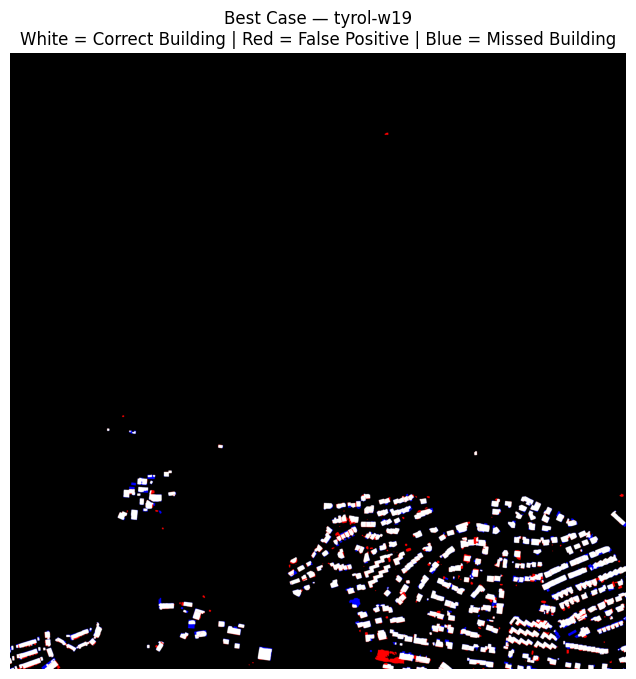

Saved: /content/drive/MyDrive/InriaDataset/Part2_Results/best_tyrol-w19_error_map.png


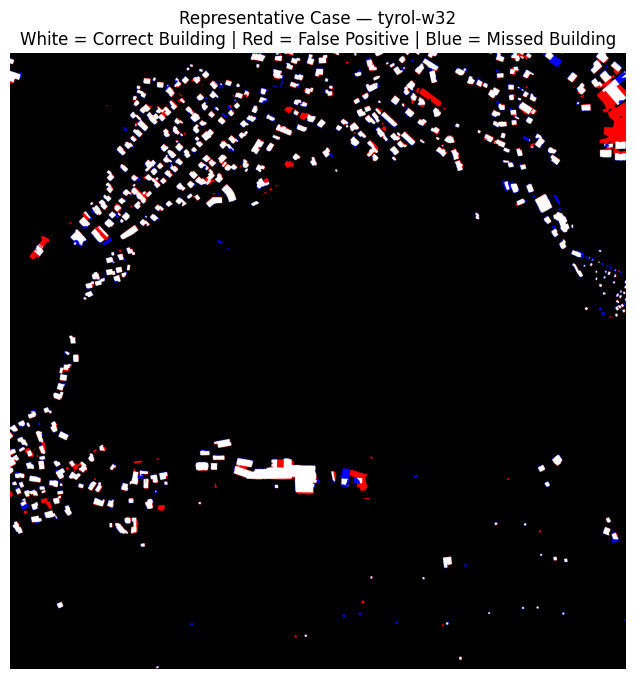

Saved: /content/drive/MyDrive/InriaDataset/Part2_Results/representative_tyrol-w32_error_map.png


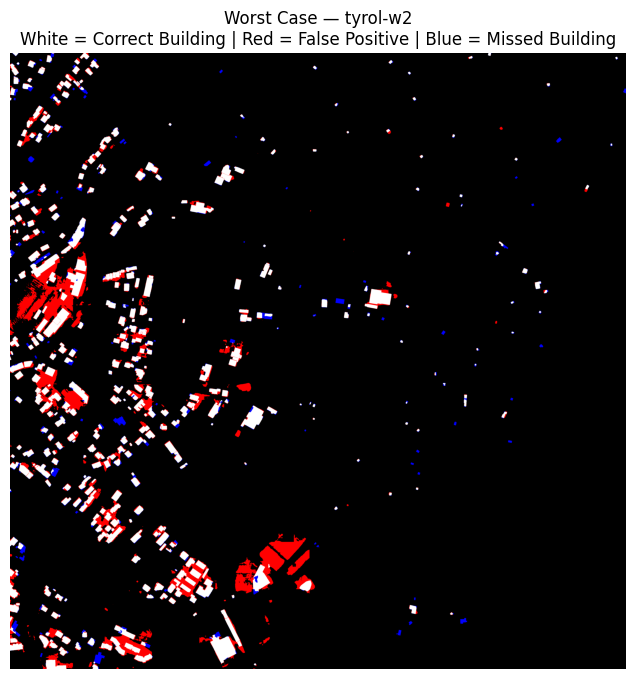

Saved: /content/drive/MyDrive/InriaDataset/Part2_Results/worst_tyrol-w2_error_map.png


In [ ]:
#Error maps for qualitative analysis

from matplotlib.colors import ListedColormap

# 0 = background/correct background
# 1 = true positive
# 2 = false positive
# 3 = false negative

error_cmap = ListedColormap([
    "black",
    "white",
    "red",
    "blue"
])


for case_name, tile_name in selected_cases.items():

    row = test_df.loc[
        test_df["tile"] == tile_name
    ].iloc[0]

    gt = np.array(
        Image.open(row["mask"]).convert("L")
    )

    gt = (gt > 127).astype(np.uint8)

    probability = predict_full_tile(
        model=model,
        image_path=row["image"],
        device=device,
        patch_size=512,
        stride=384,
        batch_size=8
    )

    pred = (
        probability >= 0.5
    ).astype(np.uint8)


    # Build error map
    error_map = np.zeros_like(
        gt,
        dtype=np.uint8
    )

    # True positives
    error_map[
        (pred == 1) & (gt == 1)
    ] = 1

    # False positives
    error_map[
        (pred == 1) & (gt == 0)
    ] = 2

    # False negatives
    error_map[
        (pred == 0) & (gt == 1)
    ] = 3


    # Plot

    plt.figure(figsize=(8, 8))

    plt.imshow(
        error_map,
        cmap=error_cmap,
        vmin=0,
        vmax=3
    )

    plt.title(
        f"{case_name} Case — {tile_name}\n"
        "White = Correct Building | "
        "Red = False Positive | "
        "Blue = Missed Building"
    )

    plt.axis("off")

    error_path = os.path.join(
        RESULTS_DIR,
        f"{case_name.lower()}_{tile_name}_error_map.png"
    )

    plt.savefig(
        error_path,
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()

    print("Saved:", error_path)

###Final test-set interpretation



In [ ]:
# Save final experiment summary

import os
import pandas as pd

final_summary = pd.DataFrame({
    "Item": [
        "Architecture",
        "Encoder",
        "Input patch size",
        "Inference stride",
        "Test city",
        "Number of test tiles",
        "Classification threshold",
        "Global IoU",
        "Global Dice",
        "Global Precision",
        "Global Recall",
        "Global Accuracy",
        "Mean tile IoU",
        "Std tile IoU",
        "Mean tile Dice",
        "Std tile Dice",
        "Best tile",
        "Best tile IoU",
        "Worst tile",
        "Worst tile IoU"
    ],

    "Value": [
        "U-Net",
        "ResNet34 (ImageNet pretrained)",
        "512 x 512",
        "384",
        "Tyrol",
        "36",
        "0.5",
        f"{global_iou:.4f}",
        f"{global_dice:.4f}",
        f"{global_precision:.4f}",
        f"{global_recall:.4f}",
        f"{global_accuracy:.4f}",
        f"{mean_metrics['IoU']:.4f}",
        f"{std_metrics['IoU']:.4f}",
        f"{mean_metrics['Dice']:.4f}",
        f"{std_metrics['Dice']:.4f}",
        best_row["tile"],
        f"{best_row['IoU']:.4f}",
        worst_row["tile"],
        f"{worst_row['IoU']:.4f}"
    ]
})

display(final_summary)

summary_file = os.path.join(
    RESULTS_DIR,
    "final_experiment_summary.csv"
)

final_summary.to_csv(
    summary_file,
    index=False
)

print("\nFinal experiment summary saved:")
print(summary_file)

,Item,Value
0,Architecture,U-Net
1,Encoder,ResNet34 (ImageNet pretrained)
2,Input patch size,512 x 512
3,Inference stride,384
4,Test city,Tyrol
5,Number of test tiles,36
6,Classification threshold,0.5
7,Global IoU,0.6857
8,Global Dice,0.8136
9,Global Precision,0.7600



Final experiment summary saved:
/content/drive/MyDrive/InriaDataset/Part2_Results/final_experiment_summary.csv


## 8. Training Convergence and Checkpoint Selection

Training and validation loss were tracked across epochs to examine model convergence and generalization. Both losses decreased substantially during training, indicating that the model learned meaningful segmentation features rather than memorizing noise.

Validation loss reached its minimum at Epoch 13 (0.4503). After this point, training loss continued to decrease while validation loss increased to 0.4975 and 0.5074 at Epochs 14 and 15 respectively — a classic divergence signature of the model beginning to overfit the training cities. The checkpoint from Epoch 13 was therefore retained for final evaluation, rather than simply using the last epoch's weights.

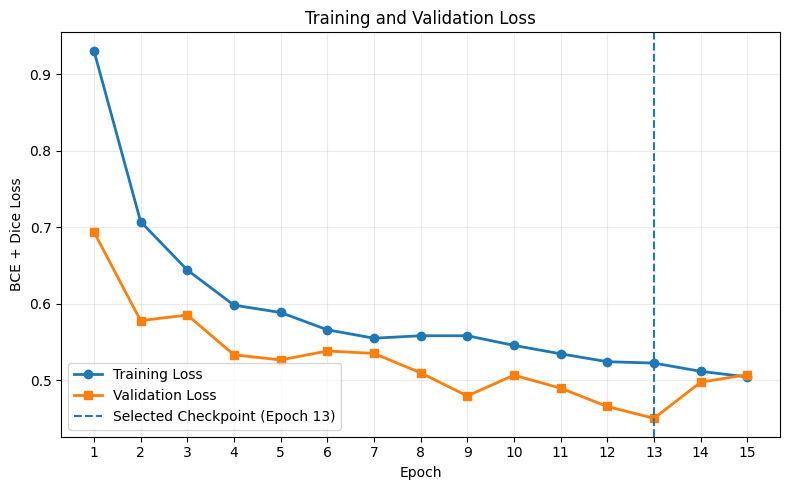

Figure saved:
/content/drive/MyDrive/InriaDataset/Part2_Results/training_validation_loss.png


In [ ]:
# Training and Validation Loss History

import matplotlib.pyplot as plt
import numpy as np
import os

# Values obtained during Step 36 training
epochs = np.arange(1, 16)

train_loss = [
    0.9306,
    0.7073,
    0.6441,
    0.5982,
    0.5886,
    0.5660,
    0.5550,
    0.5582,
    0.5582,
    0.5456,
    0.5346,
    0.5243,
    0.5225,
    0.5117,
    0.5044
]

val_loss = [
    0.6939,
    0.5779,
    0.5853,
    0.5333,
    0.5266,
    0.5383,
    0.5351,
    0.5098,
    0.4796,
    0.5067,
    0.4897,
    0.4658,
    0.4503,
    0.4975,
    0.5074
]

# Plot

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_loss,
    marker="o",
    linewidth=2,
    label="Training Loss"
)

plt.plot(
    epochs,
    val_loss,
    marker="s",
    linewidth=2,
    label="Validation Loss"
)

# Mark Epoch 13
plt.axvline(
    x=13,
    linestyle="--",
    linewidth=1.5,
    label="Selected Checkpoint (Epoch 13)"
)

plt.xlabel("Epoch")
plt.ylabel("BCE + Dice Loss")
plt.title("Training and Validation Loss")

plt.xticks(epochs)
plt.grid(alpha=0.25)
plt.legend()

plt.tight_layout()

# Save figure

loss_plot_path = os.path.join(
    RESULTS_DIR,
    "training_validation_loss.png"
)

plt.savefig(
    loss_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved:")
print(loss_plot_path)

### Validation IoU and Dice across training epochs

In addition to loss, IoU and Dice on the validation set were tracked to evaluate how segmentation quality itself changed during training (loss and the metrics that actually matter for this task don't always move in perfect lockstep, so it's worth checking both). Both metrics improved substantially during the first several epochs and reached their highest values at Epoch 13.

At Epoch 13, validation IoU reached 0.7600 and Dice reached 0.8636. Performance declined slightly during Epochs 14 and 15 even as training loss continued to decrease — consistent with the overfitting signal seen in the loss curves above. Based on validation IoU, the Epoch 13 checkpoint was selected for the final held-out Tyrol evaluation in Section 7.

Best checkpoint:
Epoch : 13
IoU   : 0.7600
Dice  : 0.8636


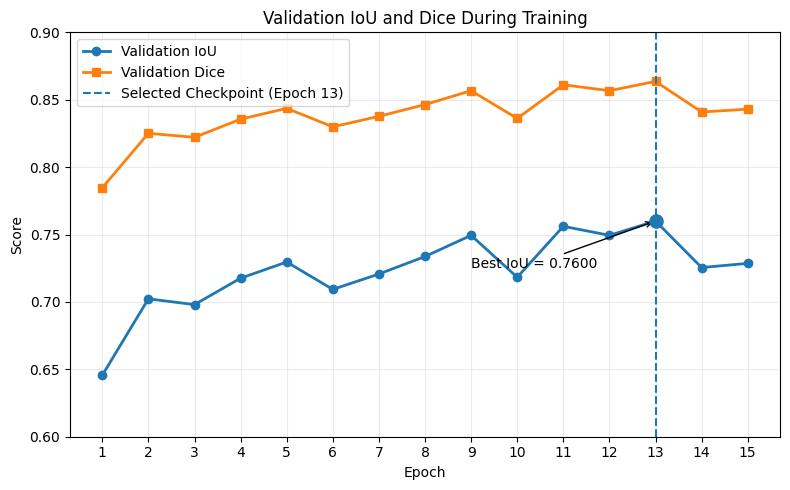


Figure saved:
/content/drive/MyDrive/InriaDataset/Part2_Results/validation_iou_dice.png


In [ ]:
# Validation IoU and Dice History

import matplotlib.pyplot as plt
import numpy as np
import os

epochs = np.arange(1, 16)

# Validation metrics recorded during Step 36
val_iou = [
    0.6456,
    0.7023,
    0.6980,
    0.7176,
    0.7296,
    0.7093,
    0.7207,
    0.7337,
    0.7494,
    0.7183,
    0.7561,
    0.7494,
    0.7600,
    0.7255,
    0.7286
]

val_dice = [
    0.7847,
    0.8251,
    0.8221,
    0.8356,
    0.8436,
    0.8299,
    0.8377,
    0.8464,
    0.8567,
    0.8361,
    0.8611,
    0.8567,
    0.8636,
    0.8409,
    0.8430
]

# Find best validation IoU

best_epoch = np.argmax(val_iou) + 1
best_iou = max(val_iou)
best_dice = val_dice[best_epoch - 1]

print("Best checkpoint:")
print(f"Epoch : {best_epoch}")
print(f"IoU   : {best_iou:.4f}")
print(f"Dice  : {best_dice:.4f}")


# Plot

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    val_iou,
    marker="o",
    linewidth=2,
    label="Validation IoU"
)

plt.plot(
    epochs,
    val_dice,
    marker="s",
    linewidth=2,
    label="Validation Dice"
)

# Mark selected checkpoint
plt.axvline(
    x=best_epoch,
    linestyle="--",
    linewidth=1.5,
    label=f"Selected Checkpoint (Epoch {best_epoch})"
)

# Highlight best IoU point
plt.scatter(
    best_epoch,
    best_iou,
    s=90,
    zorder=5
)

plt.annotate(
    f"Best IoU = {best_iou:.4f}",
    xy=(best_epoch, best_iou),
    xytext=(best_epoch - 4, best_iou - 0.035),
    arrowprops=dict(arrowstyle="->")
)

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Validation IoU and Dice During Training")

plt.xticks(epochs)
plt.ylim(0.60, 0.90)

plt.grid(alpha=0.25)
plt.legend()

plt.tight_layout()

# Save

metric_plot_path = os.path.join(
    RESULTS_DIR,
    "validation_iou_dice.png"
)

plt.savefig(
    metric_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nFigure saved:")
print(metric_plot_path)